## 02 — REGRESSOR CART: VALIDAÇÃO CRUZADA
**Objetivo**: avaliar por validação cruzada o regressor CART (`DecisionTreeRegressor`) com três **hiperparametrizações** (U, E, O), estimando a **sobr** a partir das 10 **features de entrada**, e escolher o **melhor modelo** pelo critério da spec.

* **U**: subajustada (*underfitted*)
* **E**: equilibrada
* **O**: sobreajustada (*overfitted*)

**Saídas**
* `results/cart.json`: as três hiperparametrizações (tabela 2), os MSE de treino e de validação por fold, médias, dpa e média das difs (tabela 3), e o rótulo do melhor modelo

O dataset de teste cego **não** é lido neste notebook (só no `04_teste_cego.ipynb`).

**(1) Leitura do dataset de treino/validação**

Lemos as 10.000 vítimas geradas pelo `01_dataset.ipynb`. X recebe somente as 10 features de entrada; gcs, avpu e tri são **features proibidas** e sobr é o alvo, então nenhuma delas pode estar em X.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_validate

# Caminhos
DATASET_CSV = Path("datasets/vict/10000v/data.csv")
RESULTS_JSON = Path("results/cart.json")
RESULTS_JSON.parent.mkdir(parents=True, exist_ok=True)

FEATURES_ENTRADA = ['idade', 'fc', 'fr', 'pas', 'spo2', 'temp', 'pr', 'sg', 'fx', 'queim']
FEATURES_PROIBIDAS = ['gcs', 'avpu', 'tri', 'sobr']  # sobr é o alvo
ALVO = 'sobr'

df = pd.read_csv(DATASET_CSV)
assert len(df) == 10000, f"esperado 10000 vítimas, obtido {len(df)}"

X = df[FEATURES_ENTRADA]
y = df[ALVO]

# Nenhuma feature proibida (nem o alvo) pode entrar em X
assert not set(FEATURES_PROIBIDAS) & set(X.columns), f"feature proibida em X: {set(FEATURES_PROIBIDAS) & set(X.columns)}"
assert list(X.columns) == FEATURES_ENTRADA

print(f"Arquivo.....:\t{DATASET_CSV}")
print(f"Vítimas.....:\t{len(X):>6}")
print(f"Features (X):\t{list(X.columns)}")
print(f"Alvo (y)....:\t{ALVO}  [{y.min():.4f}, {y.max():.4f}]")

Arquivo.....:	datasets/vict/10000v/data.csv
Vítimas.....:	 10000
Features (X):	['idade', 'fc', 'fr', 'pas', 'spo2', 'temp', 'pr', 'sg', 'fx', 'queim']
Alvo (y)....:	sobr  [0.0500, 1.0000]


**(2) Métricas: MSE, dpa e média das difs**

* **MSE de fold**: média dos erros quadráticos, **sem raiz** (ADR 0001). O `cross_validate` devolve o MSE negativo (`neg_mean_squared_error`), então trocamos o sinal.
* **dpa**: desvio padrão amostral dos valores por fold, com divisor k−1 (`ddof=1`).
* **Média das difs**: média sobre os folds de |MSE de treino − MSE de validação|.

Antes de usar o dpa, conferimos que ele reproduz o exemplo do enunciado: folds [0.0232, 0.0011, 0.0198] → dpa 0,0119.

In [2]:
def dpa(valores):
    # Desvio padrão amostral (divisor k-1)
    return float(np.std(valores, ddof=1))

# Exemplo numérico do enunciado
dpa_exemplo = dpa([0.0232, 0.0011, 0.0198])
assert round(dpa_exemplo, 4) == 0.0119, f"dpa do exemplo deveria ser 0,0119, obtido {dpa_exemplo:.6f}"
print(f"dpa([0.0232, 0.0011, 0.0198]) = {dpa_exemplo:.6f} ≈ {dpa_exemplo:.4f}")

dpa([0.0232, 0.0011, 0.0198]) = 0.011900 ≈ 0.0119


**(3) Hiperparametrizações (tabela 2)**

Variamos dois [hiperparâmetros](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) do CART, partindo do ponto de partida da spec (`max_depth` [2, ~8, None], `min_samples_leaf` [0.25, ~20, 1]) e ajustando até cumprir o critério de U/E/O:

* ***max_depth***: profundidade máxima da árvore (`None` = sem limite)
* ***min_samples_leaf***: número mínimo de vítimas por folha; quando é float, é uma fração das vítimas de treino do fold

1) **U**: `max_depth=2`, `min_samples_leaf=0.25` — no máximo 4 folhas, cada uma com ≥ 25% das vítimas: a árvore não consegue representar a sobr

2) **E**: `max_depth=10`, `min_samples_leaf=20` — árvore profunda o bastante para seguir a sobr, mas com folhas grandes o suficiente para não decorar o ruído (testamos `max_depth` de 8 a 12 e `min_samples_leaf` de 10 a 40; o MSE de validação estabiliza em ~0,0026 a partir de `max_depth=10`)

3) **O**: `max_depth=None`, `min_samples_leaf=1` — a árvore cresce até uma vítima por folha e decora o treino (MSE de treino ≈ 0)

Os demais hiperparâmetros ficam no padrão do scikit-learn (`criterion='squared_error'`, `min_samples_split=2`), com `random_state=42`.

In [3]:
RANDOM_STATE = 42

HIPERPARAMETRIZACOES = {
    'U': {'max_depth': 2,    'min_samples_leaf': 0.25},
    'E': {'max_depth': 10,   'min_samples_leaf': 20},
    'O': {'max_depth': None, 'min_samples_leaf': 1},
}
ROTULOS = list(HIPERPARAMETRIZACOES)
NOMES = {'U': 'Subajustada', 'E': 'Equilibrada', 'O': 'Sobreajustada'}

print("Hiper.\tmax_depth\tmin_samples_leaf")
for rotulo, hp in HIPERPARAMETRIZACOES.items():
    print(f"{rotulo}\t{str(hp['max_depth']):>9}\t{hp['min_samples_leaf']:>16}")

Hiper.	max_depth	min_samples_leaf
U	        2	            0.25
E	       10	              20
O	     None	               1


**(4) Validação cruzada**

```
Para cada hiperparametrização:
- para cada um dos k = 5 folds:
  - cross_validate treina um modelo com 4/5 das vítimas
  - calcula o MSE nas vítimas de treino e nas de validação do fold
```

O `KFold` embaralha as vítimas com `random_state=42`, então os 5 folds são **os mesmos** para as três hiperparametrizações (e para a RN no `03_rn.ipynb`).

In [4]:
K_FOLDS = 5
kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

mse_treino = {}  # MSE de treino por fold
mse_vld = {}     # MSE de validação por fold
difs = {}        # |MSE treino - MSE validação| por fold

for rotulo, hp in HIPERPARAMETRIZACOES.items():
    dt = DecisionTreeRegressor(**hp, random_state=RANDOM_STATE)

    cv_results = cross_validate(
        dt,
        X,
        y,
        cv=kfold,
        scoring='neg_mean_squared_error',  # scikit usa o MSE negativo (quanto maior o score, melhor)
        return_train_score=True,
    )

    # Troca o sinal para voltar ao MSE (sem raiz)
    mse_treino[rotulo] = -cv_results['train_score']
    mse_vld[rotulo] = -cv_results['test_score']
    difs[rotulo] = np.abs(mse_treino[rotulo] - mse_vld[rotulo])

    print(f"{rotulo} ({NOMES[rotulo]}): {dt}")

U (Subajustada): DecisionTreeRegressor(max_depth=2, min_samples_leaf=0.25, random_state=42)


E (Equilibrada): DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=42)


O (Sobreajustada): DecisionTreeRegressor(random_state=42)


**(5) Resultados da validação cruzada (tabela 3)**

Para cada hiperparametrização: MSE de treino e de validação por fold, a média e o dpa de cada um, e a média e o dpa das difs |treino − validação|.

In [5]:
resumo = {}
for rotulo in ROTULOS:
    resumo[rotulo] = {
        'mse_treino': {'media': float(mse_treino[rotulo].mean()), 'dpa': dpa(mse_treino[rotulo])},
        'mse_validacao': {'media': float(mse_vld[rotulo].mean()), 'dpa': dpa(mse_vld[rotulo])},
        'difs': {'media': float(difs[rotulo].mean()), 'dpa': dpa(difs[rotulo])},
    }

np.set_printoptions(formatter={'float': lambda v: f"{v:.6f}"})
print("MSE de treino e de validação por hiperparametrização:")
for rotulo in ROTULOS:
    r = resumo[rotulo]
    print(f"{rotulo}\tMédia\t\tdpa\t\tMSE por fold")
    print(f"Trn:\t{r['mse_treino']['media']:>8.6f}\t{r['mse_treino']['dpa']:>8.6f}\t{mse_treino[rotulo]}")
    print(f"Vld:\t{r['mse_validacao']['media']:>8.6f}\t{r['mse_validacao']['dpa']:>8.6f}\t{mse_vld[rotulo]}")
    print(f"Dif:\t{r['difs']['media']:>8.6f}\t{r['difs']['dpa']:>8.6f}\t{difs[rotulo]}")
    print()

tabela3 = pd.DataFrame({
    rotulo: {
        'MSE treino (média)': r['mse_treino']['media'],
        'MSE treino (dpa)': r['mse_treino']['dpa'],
        'MSE validação (média)': r['mse_validacao']['media'],
        'MSE validação (dpa)': r['mse_validacao']['dpa'],
        'Média das difs': r['difs']['media'],
        'dpa das difs': r['difs']['dpa'],
    }
    for rotulo, r in resumo.items()
}).T
tabela3.style.format('{:.6f}')

MSE de treino e de validação por hiperparametrização:
U	Média		dpa		MSE por fold
Trn:	0.009462	0.000059	[0.009379 0.009439 0.009485 0.009468 0.009541]
Vld:	0.009468	0.000238	[0.009802 0.009561 0.009378 0.009446 0.009155]
Dif:	0.000212	0.000180	[0.000423 0.000122 0.000107 0.000022 0.000386]

E	Média		dpa		MSE por fold
Trn:	0.001968	0.000013	[0.001961 0.001974 0.001978 0.001979 0.001949]
Vld:	0.002614	0.000058	[0.002690 0.002564 0.002658 0.002560 0.002596]
Dif:	0.000646	0.000062	[0.000729 0.000590 0.000680 0.000581 0.000647]

O	Média		dpa		MSE por fold
Trn:	0.000000	0.000000	[0.000000 0.000000 0.000000 0.000000 0.000000]
Vld:	0.004066	0.000133	[0.004187 0.004141 0.004142 0.003867 0.003995]
Dif:	0.004066	0.000133	[0.004187 0.004141 0.004142 0.003867 0.003995]



,MSE treino (média),MSE treino (dpa),MSE validação (média),MSE validação (dpa),Média das difs,dpa das difs
U,0.009462,0.000059,0.009468,0.000238,0.000212,0.000180
E,0.001968,0.000013,0.002614,0.000058,0.000646,0.000062
O,0.000000,0.000000,0.004066,0.000133,0.004066,0.000133


Vamos comparar graficamente as três hiperparametrizações, fold a fold. A linha cheia é o MSE de treino e a tracejada o de validação; a distância entre elas é a dif de cada fold. A linha cinza pontilhada marca o piso de ruído da sobr (~0,0016 = 0,04²).

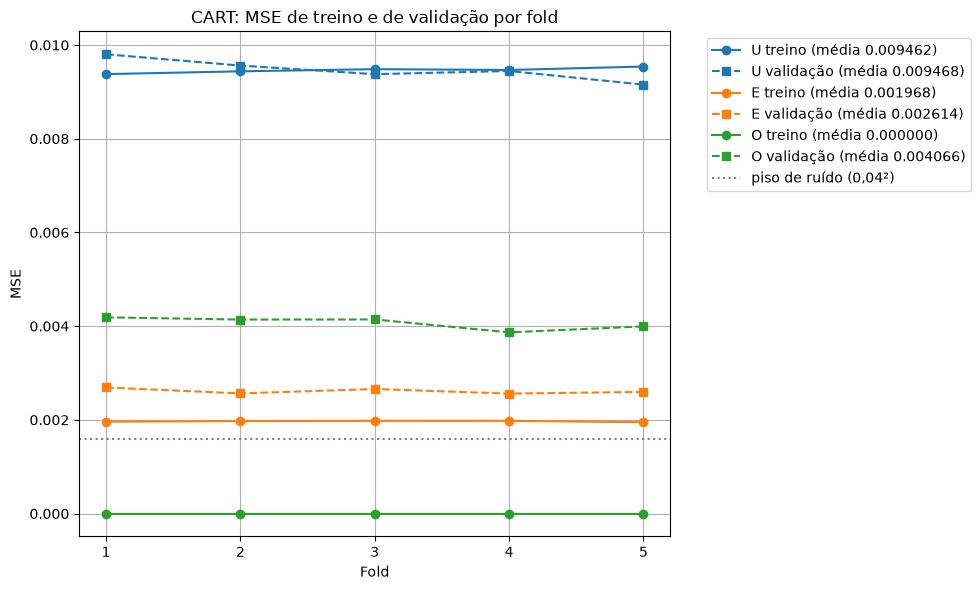

In [6]:
CORES = {'U': 'tab:blue', 'E': 'tab:orange', 'O': 'tab:green'}
folds = np.arange(1, K_FOLDS + 1)

plt.figure(figsize=(10, 6))
for rotulo in ROTULOS:
    plt.plot(folds, mse_treino[rotulo], marker='o', color=CORES[rotulo],
             label=f"{rotulo} treino (média {resumo[rotulo]['mse_treino']['media']:.6f})")
    plt.plot(folds, mse_vld[rotulo], marker='s', linestyle='--', color=CORES[rotulo],
             label=f"{rotulo} validação (média {resumo[rotulo]['mse_validacao']['media']:.6f})")
plt.axhline(0.04 ** 2, color='gray', linestyle=':', label='piso de ruído (0,04²)')

plt.xlabel("Fold")
plt.ylabel("MSE")
plt.title("CART: MSE de treino e de validação por fold")
plt.xticks(folds)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()

**(6) Critério de U/E/O e melhor modelo**

Critério de **melhor modelo** (spec, issue #1):
1. menor MSE médio de validação;
2. **empate técnico**: hiperparametrizações com MSE médio de validação dentro de 5% do menor valor;
3. entre as empatadas, desempate pelo menor dpa de validação e, depois, pela menor média das difs.

E verificamos o critério de U/E/O: U tem o maior MSE médio de validação dos três (com treino ≈ validação), O tem a maior média das difs (treino claramente abaixo da validação) e o critério de melhor modelo escolhe E.

In [7]:
TOLERANCIA_EMPATE = 0.05  # empate técnico: até 5% acima do menor MSE médio de validação

def melhor_modelo(resumo, tolerancia=TOLERANCIA_EMPATE):
    menor_vld = min(r['mse_validacao']['media'] for r in resumo.values())
    limite = menor_vld * (1 + tolerancia)
    empatados = [rot for rot, r in resumo.items() if r['mse_validacao']['media'] <= limite]
    # Desempate: menor dpa de validação, depois menor média das difs
    melhor = min(empatados, key=lambda rot: (resumo[rot]['mse_validacao']['dpa'], resumo[rot]['difs']['media']))
    return melhor, empatados, limite

melhor, empatados, limite_empate = melhor_modelo(resumo)

print(f"Menor MSE médio de validação.:\t{limite_empate / (1 + TOLERANCIA_EMPATE):.6f}")
print(f"Limite do empate técnico (5%):\t{limite_empate:.6f}")
print(f"Empatados....................:\t{empatados}")
print(f"Melhor modelo................:\t{melhor} ({NOMES[melhor]}) {HIPERPARAMETRIZACOES[melhor]}")

# Critério de U/E/O
maior_vld = max(ROTULOS, key=lambda rot: resumo[rot]['mse_validacao']['media'])
maior_dif = max(ROTULOS, key=lambda rot: resumo[rot]['difs']['media'])
print(f"Maior MSE médio de validação.:\t{maior_vld}")
print(f"Maior média das difs.........:\t{maior_dif}")

assert maior_vld == 'U', f"U deveria ter o maior MSE médio de validação, mas foi {maior_vld}"
assert maior_dif == 'O', f"O deveria ter a maior média das difs, mas foi {maior_dif}"
assert melhor == 'E', f"o critério de melhor modelo deveria escolher E, mas escolheu {melhor}"
# O: treino claramente abaixo da validação
assert resumo['O']['mse_treino']['media'] < resumo['O']['mse_validacao']['media']

Menor MSE médio de validação.:	0.002614
Limite do empate técnico (5%):	0.002744
Empatados....................:	['E']
Melhor modelo................:	E (Equilibrada) {'max_depth': 10, 'min_samples_leaf': 20}
Maior MSE médio de validação.:	U
Maior média das difs.........:	O


**(7) Gravação em `results/cart.json`**

Este JSON é lido pelo `04_teste_cego.ipynb` para montar as tabelas 2 e 3 do relatório e para retreinar o melhor modelo com as 10.000 vítimas.

In [8]:
resultado = {
    'algoritmo': 'CART (DecisionTreeRegressor)',
    'features_entrada': FEATURES_ENTRADA,
    'alvo': ALVO,
    'validacao_cruzada': {
        'k_folds': K_FOLDS,
        'shuffle': True,
        'random_state': RANDOM_STATE,
        'scoring': 'neg_mean_squared_error',
    },
    # Tabela 2
    'hiperparametrizacoes': {
        rotulo: {
            'nome': NOMES[rotulo],
            'max_depth': hp['max_depth'],
            'min_samples_leaf': hp['min_samples_leaf'],
            'random_state': RANDOM_STATE,
        }
        for rotulo, hp in HIPERPARAMETRIZACOES.items()
    },
    # Tabela 3
    'resultados': {
        rotulo: {
            'mse_treino_folds': mse_treino[rotulo].tolist(),
            'mse_validacao_folds': mse_vld[rotulo].tolist(),
            'difs_folds': difs[rotulo].tolist(),
            **resumo[rotulo],
        }
        for rotulo in ROTULOS
    },
    'criterio_melhor': {
        'tolerancia_empate': TOLERANCIA_EMPATE,
        'limite_empate': limite_empate,
        'empatados': empatados,
    },
    'melhor': melhor,
}

with open(RESULTS_JSON, 'w', encoding='utf-8') as f:
    json.dump(resultado, f, indent=2, ensure_ascii=False)
    f.write('\n')

# Confere o que foi gravado
with open(RESULTS_JSON, encoding='utf-8') as f:
    relido = json.load(f)
assert relido['melhor'] == 'E'
assert set(relido['hiperparametrizacoes']) == set(relido['resultados']) == {'U', 'E', 'O'}
assert all(len(r['mse_validacao_folds']) == K_FOLDS for r in relido['resultados'].values())

print(RESULTS_JSON.read_text(encoding='utf-8'))

{
  "algoritmo": "CART (DecisionTreeRegressor)",
  "features_entrada": [
    "idade",
    "fc",
    "fr",
    "pas",
    "spo2",
    "temp",
    "pr",
    "sg",
    "fx",
    "queim"
  ],
  "alvo": "sobr",
  "validacao_cruzada": {
    "k_folds": 5,
    "shuffle": true,
    "random_state": 42,
    "scoring": "neg_mean_squared_error"
  },
  "hiperparametrizacoes": {
    "U": {
      "nome": "Subajustada",
      "max_depth": 2,
      "min_samples_leaf": 0.25,
      "random_state": 42
    },
    "E": {
      "nome": "Equilibrada",
      "max_depth": 10,
      "min_samples_leaf": 20,
      "random_state": 42
    },
    "O": {
      "nome": "Sobreajustada",
      "max_depth": null,
      "min_samples_leaf": 1,
      "random_state": 42
    }
  },
  "resultados": {
    "U": {
      "mse_treino_folds": [
        0.009379206999308777,
        0.009438907748683004,
        0.009484696360063076,
        0.009467594190735128,
        0.009540563542004374
      ],
      "mse_validacao_folds": [
    